In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set global font to Helvetica
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.size'] = 15 

'\nThis script reads in seismic spectral Probability Density Functions (PDFs) from the MUSTANG database and plots them.\n'

In [ ]:
tlist = [
        #  ['2007-02-15', '2007-03-09'], 
        #  ['2008-02-15', '2008-03-09'],
         ['2009-02-15', '2009-03-15'],
         ['2010-02-15', '2010-03-15'],
         ['2011-02-15', '2011-03-15'],
         ['2012-02-15', '2012-03-15'],
         ['2013-02-15', '2013-03-15'],
         ['2014-02-15', '2014-03-15'],
         ['2015-02-15', '2015-03-15'],
         ['2016-02-15', '2016-03-15'],
         ['2017-02-15', '2017-03-15'],
         ['2018-02-15', '2018-03-15'],
         ['2019-02-15', '2019-03-15'],
         ['2020-02-15', '2020-03-15'],
         ['2021-02-15', '2021-03-15'],
         ['2022-02-15', '2022-03-15'],
         ['2023-02-15', '2023-03-15'],
         ['2024-02-15', '2024-03-15'],
         ]


In [ ]:
import pandas as pd
from dateutil.relativedelta import relativedelta

# Get Ice Cover Data

path2data = "./noaa_coastwatch_data/"

ice_avg = []
ice_pct = {}
ice_date = {}
ice_date_mthday = {}
for iyr in range(len(tlist)):
    year_start = str(int(tlist[iyr][0][0:4])-1)
    year_end = tlist[iyr][0][0:4]
    datafile = path2data+"g"+year_start+"_"+year_end+"_ice.dat"
    df = pd.read_fwf(datafile, header=None, skiprows=8, names=["year", "day", "sup", "mich", "huron", "erie", "ont", "stclr", "gltot"])

    # Convert year and doy to datetime
    combined = df["year"]*1000 + df["day"]
    df["date"] = pd.to_datetime(combined, format = "%Y%j")
    
    # Get month-day by subtracting everything to a common year
    df['mthday']=df['date']
    for iday in range(len(df['mthday'])):
        df['mthday'][iday] = df['mthday'][iday] - relativedelta(years=iyr)

    # Mask between dates of interest
    start_date = pd.to_datetime(tlist[iyr][0],format='%Y-%m-%d')
    end_date = pd.to_datetime(tlist[iyr][1],format='%Y-%m-%d')

    #greater than the start date and smaller than the end date
    mask = (df['date'] >= start_date) & (df['date'] <= end_date)

    df_mask = df.loc[mask]

    ice_avg.append(df_mask['sup'].mean())

    ice_pct[iyr] = df['sup']
    ice_date[iyr] = df['date']
    ice_date_mthday[iyr] = df['mthday']

ice_avg = np.asarray(ice_avg)


# Plot ice averages

# hh, ax = plt.subplots()

# ax.plot(years, ice_avg, '-o',
#               c='r', lw=2)

# ax.set_xlabel('Year')
# ax.set_ylabel('Ice Cover (%)')
# ax.set_title('Ice Cover Lake Superior (Feb 15 - March 15)')
# ax.legend()


/tmp/ipykernel_15466/65231365.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mthday'][iday] = df['mthday'][iday] - relativedelta(years=iyr)
/tmp/ipykernel_15466/65231365.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mthday'][iday] = df['mthday'][iday] - relativedelta(years=iyr)
/tmp/ipykernel_15466/65231365.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mthday'][iday] = df['mthday'][iday] - relativedelta(

/tmp/ipykernel_15466/1169664303.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral')
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


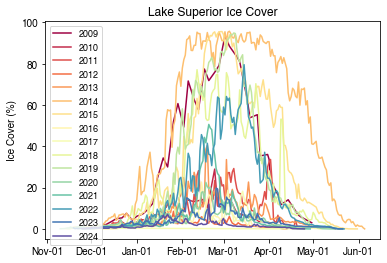

In [ ]:
# Plot all ice curves together

import matplotlib.cm as cm
import matplotlib.dates as mdates

cmap = cm.get_cmap('Spectral')
rgb = cmap(np.linspace(0,1,len(tlist)))

# hh, ax = plt.subplots(figsize=(6.4*2, 4.8*2))
# hh, ax = plt.subplots(figsize=(6.4, 4.8))
hh, ax = plt.subplots()

for iyr in range(len(tlist)):

    ax.plot(ice_date_mthday[iyr], ice_pct[iyr],
            c=rgb[iyr], lw=1.5, linestyle='-', label=tlist[iyr][0][0:4])

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
# ax.set_xlabel('Date')
# ax.set_ylim([-190, -100])
ax.set_ylabel('Ice Cover (%)')
ax.set_title('Lake Superior Ice Cover')
ax.legend(bbox_to_anchor=(1.25, 1.0))
ax.legend(loc='upper left',fontsize=8)
# ax.get_xlim(ice_date_mthday[0].min(), ice_date_mthday[0].max())

plt.savefig('./figs/a2_icecover_Superior.pdf', bbox_inches='tight')